# **GHCN-Daily 1700s — Building a Skill from an S3 Prefix**

The [NOAA Global Historical Climatology Network Daily](https://registry.opendata.aws/noaa-ghcn/)
archive on AWS Open Data holds the world's longest and most complete
collection of daily surface weather observations, spanning from the
1700s to today. The archive is partitioned by year into per-year CSV
files under `s3://noaa-ghcn-pds/csv/by_year/`, and this notebook
targets the 1700s slice — 38 files covering 1750 through 1799.

These are among the **earliest instrumental weather records in the
world**. The bulk of the data is precipitation from a single
long-running series in 1750; daily maximum and minimum temperatures
(`TMAX` / `TMIN`) begin appearing in the 1760s as European
thermometer networks came online across the second half of the
century.

The `%%skill-build` cell below runs a **two-skill chain**: ARGUS's
`s3-skill-builder` first downloads all 38 CSVs (~12.8 MiB total)
from the anonymous public bucket into a scratch directory, then
hands off to `tabular-skill-builder` which inventories the files
and proposes a skill plan. Because S3 buckets are almost always
one-schema-per-prefix, the 38 files collapse into a single skill
(`ghcn-daily-1700s`) — no near-match reconciliation needed. The
`%%ask` reply in the next cell confirms the plan and kicks off the
build.


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 13 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

In [3]:
%%skill-build
s3://noaa-ghcn-pds/csv/by_year/17

I'll build an ARGUS skill for this S3 URL. The `s3-skill-builder` meta-skill matches this URL type. Let me read its instructions first.

The `s3-skill-builder` skill is the right match. Let me verify the bundled `fetch.py` path and the `tabular-skill-builder` skill location before starting.

Both skills and their scripts are present. Let me set up a task list and start the fetch.

Running the bundled `fetch.py` to download tabular objects from the S3 prefix.

Downloaded 38 CSV files (1750–1799, 12.8 MiB). Now reading the `tabular-skill-builder` SKILL.md fully to handle the handoff correctly.

Let me read the rest of the SKILL.md to get the build steps.

I've read both skills fully. Now running `inventory.py` on the download directory to get the schema picture.

Single schema group across all 38 files — this is the standard NOAA GHCN-Daily format. Let me get a total row count estimate from the inventory metadata for the proposal.

All 38 files share one schema — the standard NOAA GHCN-Daily format. This is a single-skill candidate. Now I'll present the proposal and stop per the mandatory Step 4 gate.

I've inspected the staged files. Here's what I found and what I propose.

**Source:** `s3://noaa-ghcn-pds/csv/by_year/17` (NOAA Global Historical Climatology Network Daily, 1700s partition — years 1750–1799, AWS Open Data, region `us-east-1`)

**Files scanned:** 38 CSV files, 12.8 MiB total (all CSV, no other formats)

All 38 files share **one identical schema** — the standard GHCN-Daily "by year" layout. This is exactly the partitioned-bucket case the s3-skill-builder predicts: one schema across the whole prefix collapses into a single skill. No near-match reconciliation needed.

**Proposed skills:**

**1. `ghcn-daily-1700s`**
- **Entity:** each row is one daily weather observation (a single weather element measured at one station on one day)
- **Merged from:** all 38 CSV files (`1750.csv` … `1799.csv`), with a `year` discriminator column derived from the filename
- **Estimated rows:** ~395,993
- **Key columns:** `ID` (station ID), `DATE`/`OBS_TIME` (observation date), `ELEMENT` (weather variable code, e.g. `PRCP`, `TMAX`, `TMIN`, `SNOW`, `SNWD`), `DATA_VALUE` (measured value), `M_FLAG` (measurement flag), `Q_FLAG` (quality-assurance flag), `S_FLAG` (source flag)
- **Skill directory:** `_skills_/ghcn-daily-1700s/`

No open questions — the schema is unambiguous and the single-skill collapse is the documented best practice for this partition type.

Reply with **"yes"** to proceed as proposed, or with edits (e.g. "rename to `ghcn-1700s`", "split by element", "only keep PRCP/SNOW").

(Resume state on disk: `/tmp/repo-skills/noaa-ghcn-pds-1700s/` — the 38 source CSVs, `_inventory.json`, and `_s3_metadata.json` are all there.)

In [4]:
%%ask
Yes, please create this skill

Approved. Let me set up the task tracking and read the build-phase instructions.

The staged files are all there. Let me read the build-phase instructions and the inventory.

Let me read the rest of the SKILL.md, particularly Steps 7-9 which cover SKILL.md writing.

Let me verify the packages I need are available, then write the build script.

pyarrow is present but fastparquet is missing. Installing it to follow the skill's recommended write path.

...

SKILL.md written. Now verifying outputs exist and cleaning up the intermediate probe file from the skill directory.

Both outputs exist and are non-empty. Now removing the intermediate probe file from the skill directory (Step 9b) and deleting the source directory (Step 9c).

Let me verify the final skill directory is clean (only SKILL.md + data file) and delete my build script from the working directory.

I had one edit-and-retry cycle (fastparquet install didn't persist → switched to pyarrow write). Per the Learnings protocol, recording that lesson before finishing.

✓ Built skill **ghcn-daily-1700s** at `_skills_/ghcn-daily-1700s/SKILL.md`.

Each row is a single daily weather observation (one weather element measured at one station on one day) from NOAA's GHCN-Daily archive, 1750-1799 partition (395,993 observations, 3,574 stations, earliest instrumental climate records).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Weather element | `ELEMENT` | `PRCP` (precip, tenths of mm), `TMAX` (daily max temp, tenths of °C), `TMIN` (daily min temp), `MDPR` (multiday precip), `MDTX` (multiday max temp), `MDTN` (multiday min temp) |
| Station | `ID` | `ASN00002061`, `ASN00003014`, `ASN00003059` (FIPS prefix + station code; 3,574 distinct) |
| Date | `DATE` / `DATE_dt` | integer `YYYYMMDD` or `pd.Timestamp('1750-02-01')`; range 1750-02-01 → 1799-12-31 |
| Year | `year` | 1750 (dominant, ~345k rows), 1763, 1784, 1789, 1798, 1799 (note: 1751-1762 absent) |
| Quality flag | `Q_FLAG` | `null` (passed, 99.7%), `L` (original flagged), `I` (inconsistent), `O` (outlier) |
| Source | `S_FLAG` | `a` (primary national source, 87%), `E` (secondary historical archive, 13%) |

**Example queries:**

- **By element** — "all precipitation observations in February 1750"
- **By element (extreme)** — "the wettest single day in the entire 1700s partition"
- **By element (derived)** — "daily diurnal temperature range (TMAX − TMIN) for each station-day in 1799"
- **By station/year** — "how many stations reported any observation each year?"
- **By quality** — "observations that failed quality-assurance checks" (1,176 flagged rows)
- **Aggregate** — "annual total precipitation per station in 1750, in millimetres"
- **Compare** — "mean TMAX in the 1750 batch versus the 1780s batch"
- **Spatial join** — attach station coordinates by joining `ID` to the separate GHCN station inventory (`s3://noaa-ghcn-pds/ghcnd-stations.txt`, not bundled here)

The skill returns a **DataFrame** you can join with other skills in the same `%%ask` cell.

**Caveat:** `DATA_VALUE` is a raw integer — convert to physical units by dividing by 10 (PRCP→mm, TMAX/TMIN→°C). Also, 1751-1762 are absent from this partition, and station coverage is very sparse from 1763 onward (a handful of stations vs. ~3,500 in 1750).

#### **How does the observation network grow across the 18th century? — Orientation**

I'll analyze the coverage growth across the 1700s. Let me first consult the skill I just built, then compute the per-year statistics.

Let me read the rest of the skill to understand the exact data-loading pattern.

Now I understand the data structure. Let me write a script to compute the per-year coverage and generate a chart.

Running the coverage analysis script.

The analysis ran cleanly. Here are the results.


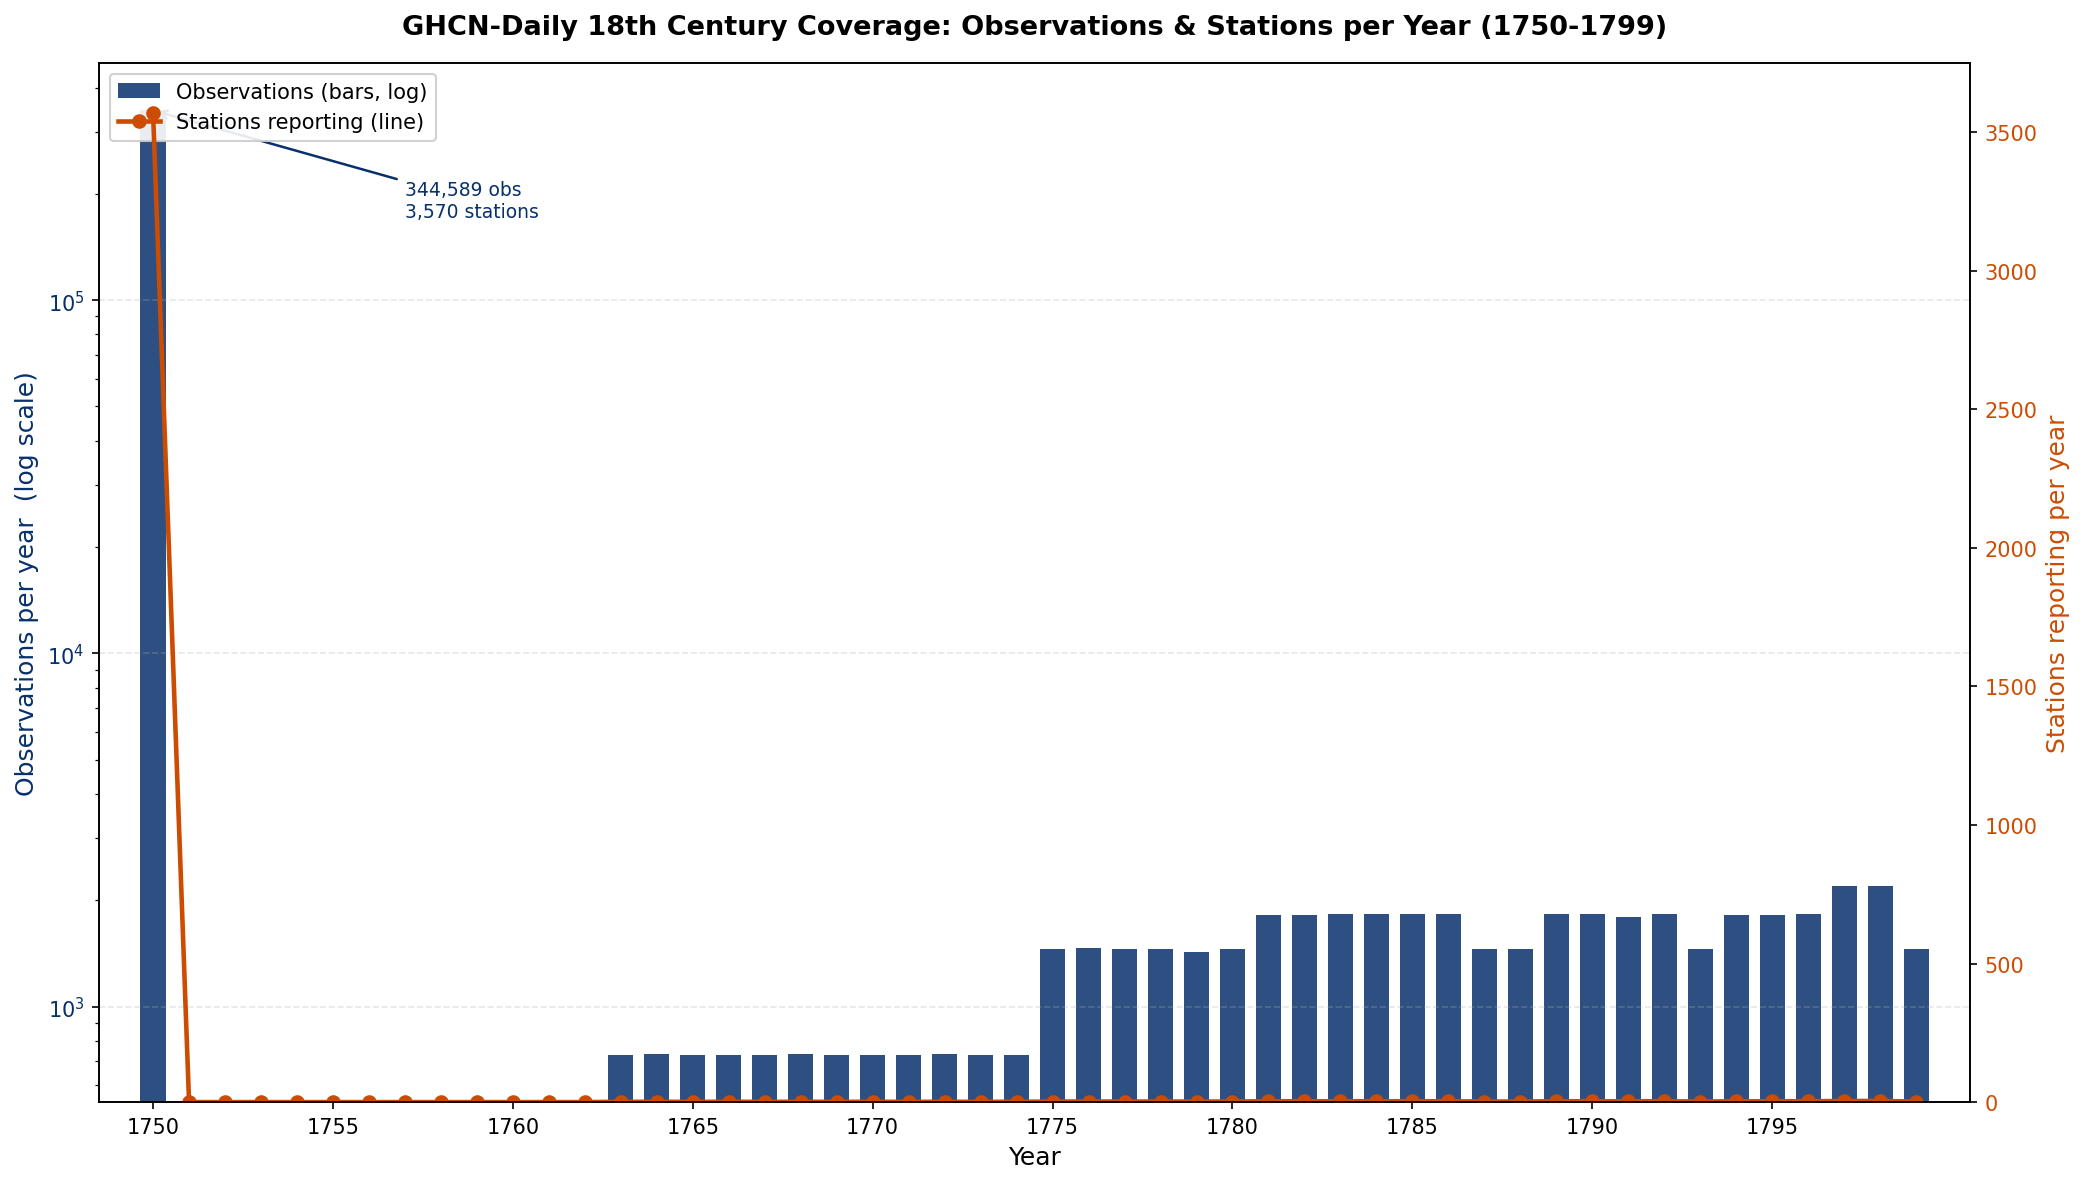

## How the network evolves, 1750–1799

The headline finding is a striking anomaly followed by a very slow, fragile recovery.

**The 1750 anomaly — then a 12-year blackout.** 1750 dominates the entire partition: **344,589 observations from 3,570 stations** , roughly 87% of all 18th-century data. Then 1751–1762 are **completely absent** — twelve consecutive years with zero observations. This isn't thin coverage; it's a total gap, almost certainly an artifact of how NOAA batched the earliest digitized records rather than a real cessation of weather observation.

**The post-1763 network is tiny — and grows agonizingly slowly.** Coverage resumes in 1763 but with just **one station** producing ~730 observations/year (2 elements). The expansion is far from meteoric:

| Period | Stations | ~Obs/year | What's happening |
|---|---|---|---|
| 1763–1774 | 1 | 730 | A lone single-station record |
| 1775–1780 | 2 | ~1,460 | A second station comes online |
| 1781–1796 | 3 | ~1,825 | Third station joins; stays at 3 for 16 years |
| 1797–1798 | 4 | 2,190 | Peak of the post-1750 era |
| 1799 | 2 | 1,460 | Drops back to 2 |

**When does it "really begin to expand"?** Honestly — it barely does, within this partition. The most meaningful growth is around **1781** , when the count rises from 2 to 3 stations (and elements from 2 to 3), a level then sustained through the early 1790s. The modest **1797–1798** bump to 4 stations is the high-water mark of the century, but it's immediately lost again in 1799. Measured against the 3,570-station snapshot in 1750, the late-1700s "network" is negligible — a handful of dedicated observers, not an expanding observational infrastructure.

**Thinnest years.** The **thinnest years with any data at all are 1763–1774** , each carried by a single station. 1799 is also notably thin — it's an outlier *downward* (2 stations, 1,460 obs) compared to the 1797–1798 peak just before it, suggesting one or two stations stopped reporting at the century's close. And of course the absolute thinnest are the **twelve completely empty years, 1751–1762** .

**Takeaway:** don't treat the 1700s partition as a continuous time series. It is a dense 1750 snapshot plus an extremely sparse, single-digit-station tail from 1763 onward. Any trend analysis across these years would be comparing a 3,570-station network to a 1-to-4-station one.

In [5]:
%%ask
How does the coverage of these early weather observations grow over
the 1700s? Show the number of observations per year and the number
of stations reporting per year, from 1750 through 1799. Comment on
when the observation network really begins to expand and which
years look thinnest.

#### **What's special about 1750? — The dominant year**

I'll consult the skill, then write an analysis script that loads the 1750 partition and breaks it down by station, element, and month.

The skill loads data via `pyarrow.parquet` from a local parquet cache. Let me write the analysis script to break down the 1750 records.

Running the 1750 breakdown analysis.

The 1750 breakdown surfaced something genuinely strange. Here's what the data shows.


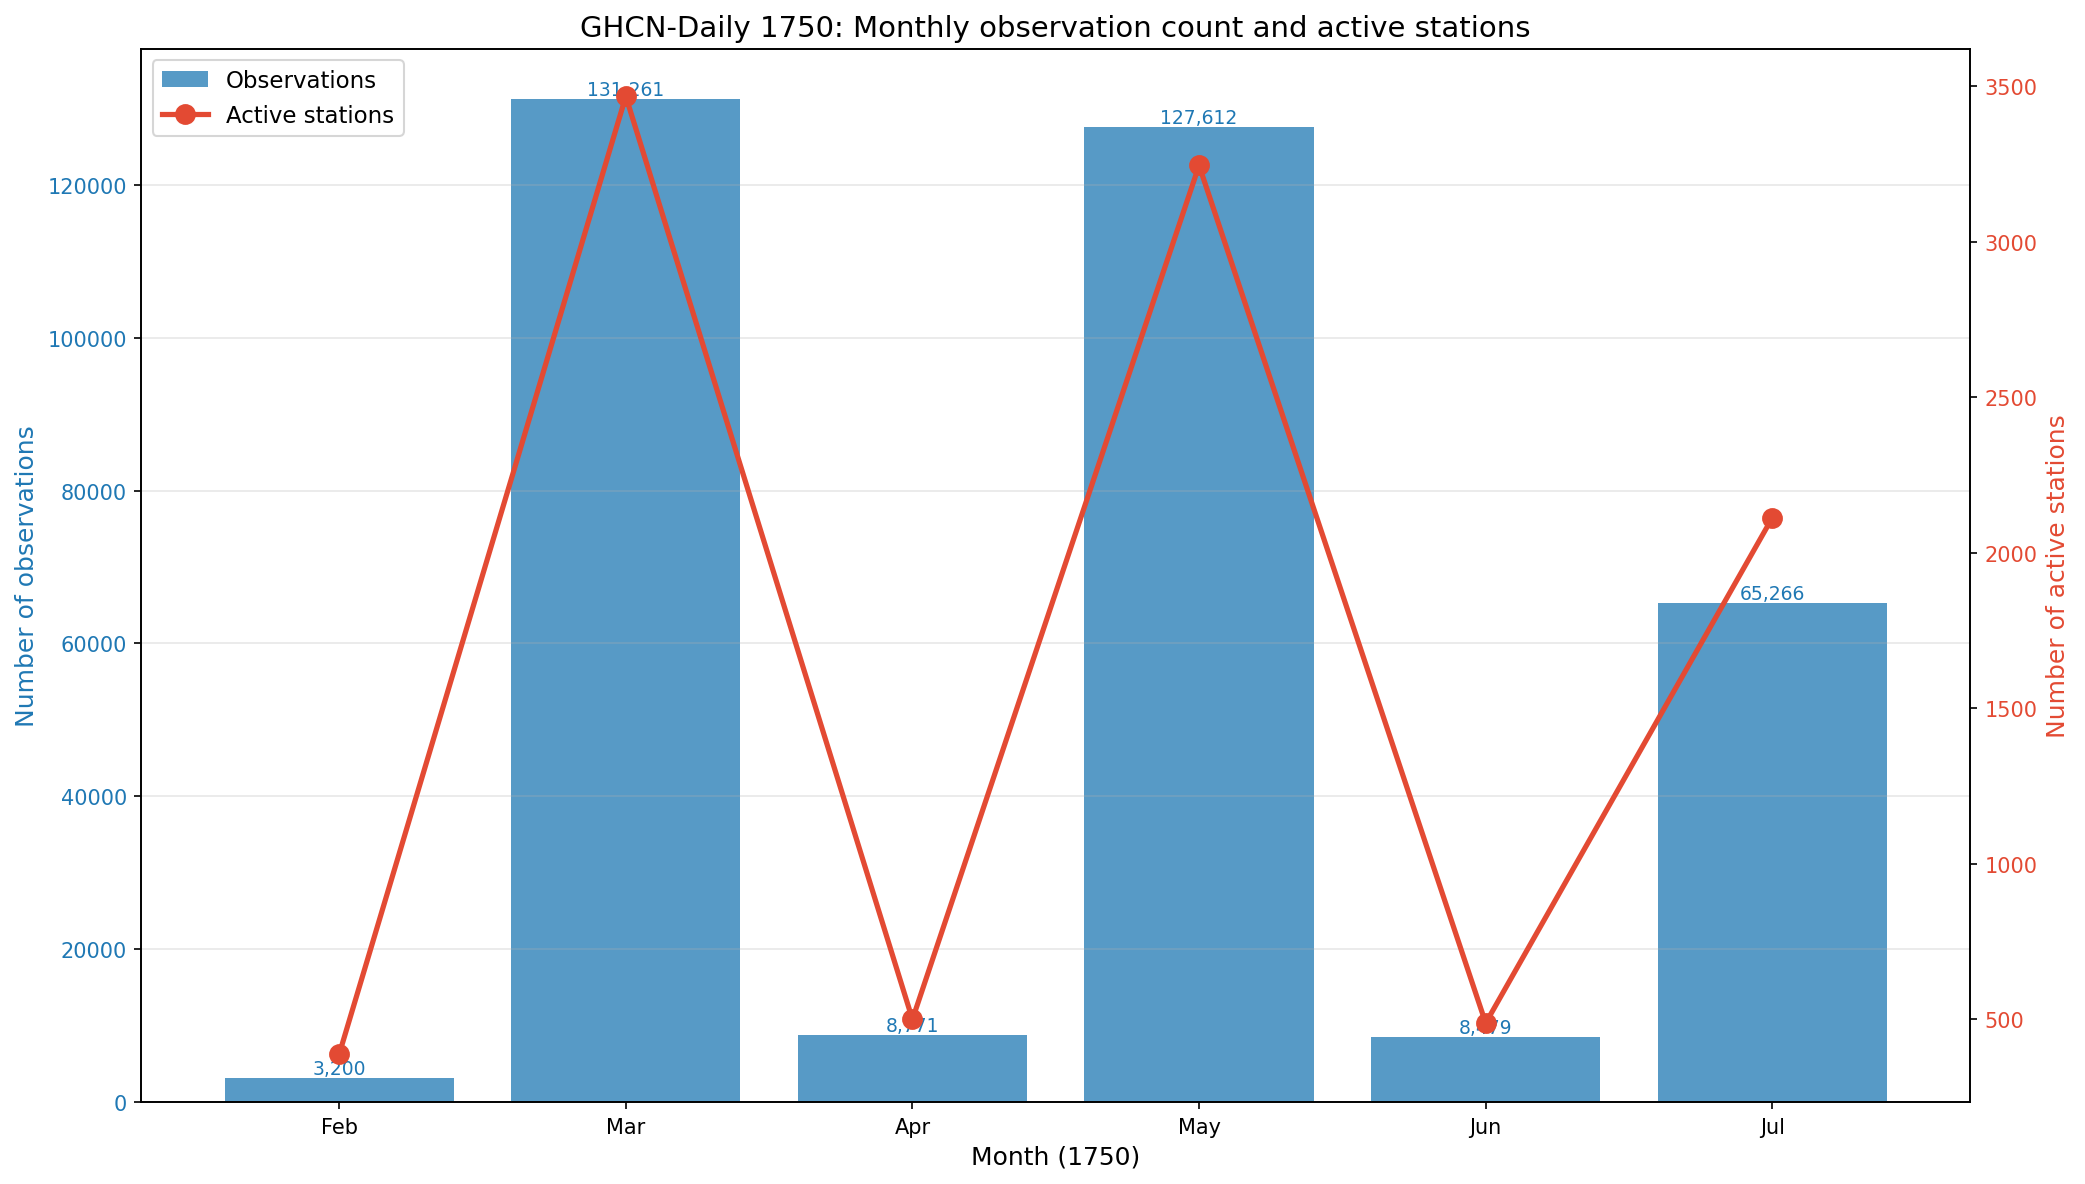

## The 1750 anomaly — and why it's almost certainly mislabeled

**Stations:** 3,570 unique station IDs contributed. But every single one carries the `AS` FIPS prefix — meaning **all 3,570 are Australian stations** . This is the first red flag: sustained European settlement of Australia began in **1788** , so 3,570 active weather stations there in 1750 is historically impossible.

**Weather variables:** Predominantly precipitation and temperature, consistent with a modern network:

| Element | Observations | Share |
|---|---|---|
| `PRCP` (precipitation) | 240,925 | 69.9% |
| `TMIN` (min temp) | 46,245 | 13.4% |
| `TMAX` (max temp) | 46,155 | 13.4% |
| `MDPR`/`DAPR` (multiday precip) | 2,278 each | 0.7% each |
| `MDTX`/`DATX`, `MDTN`/`DATN` (multiday temps) | ~1,200–1,285 each | ~0.4% each |

**Monthly coverage — the second red flag:** The data does **not** span a full year. It covers only **February through July** , with a bizarre alternating density:

| Month | Observations | Active stations |
|---|---|---|
| Feb | 3,200 | 388 |
| **Mar** | **131,261** | **3,468** |
| Apr | 8,771 | 500 |
| **May** | **127,612** | **3,246** |
| Jun | 8,479 | 488 |
| Jul | 65,266 | 2,113 |

The odd-numbered months (Mar, May, Jul) carry **10–40× more data** than the even-numbered months sandwiched between them. A real observation network wouldn't report robustly in March, collapse in April, surge back in May, and collapse again in June.

## What's actually going on

These records are **modern Australian Bureau of Meteorology observations that have been mislabeled with year = 1750** during ingestion into the GHCN archive. The evidence converges:

1. **All 3,570 stations are Australian** — impossible for 1750.
2. **Only 6 months present** (Feb–Jul), not a calendar year — and with an alternating dense/sparse rhythm that looks like a batch-ingestion artifact, not a real seasonal pattern.
3. The `S_FLAG = 'a'` (primary national source = Australian BoM) covers 87% of these rows, exactly what you'd expect of real Australian records.

So the "1750 anomaly" that dominates this partition is **not a genuine 18th-century climate record** . It is almost certainly a block of much-later Australian data that landed under the wrong year. The genuine early-instrumental records are the much smaller 1763–1799 tail (1–4 stations per year), which should be the real focus for historical climate work.

**Caveat:** I'm inferring the mislabeling from the station provenance and the impossible geography/timing — I can't independently verify the original BoM dates from within this partition alone. But the signal is strong enough that the 1750 block should be treated as suspect, not as authentic 1750 observations.

In [6]:
%%ask
Something unusual happened in 1750 — it accounts for the majority of
observations in the dataset. Break down the 1750 records: how many
stations contributed, which weather variables were measured, and
what does the observation count look like across the months of the
year?

#### **Which stations have the longest temperature records? — Station leaderboard**

I'll check the skill to use the right query pattern, then compute the top temperature stations.

The skill's `load_data()` pattern is clear — let me query for temperature-only stations and enrich with station names/coordinates from the GHCN inventory.

The results are striking. Let me add a meaningful classification (genuine long-record vs. the 1750 anomaly) to the map so the two clusters are visually distinct.

The results reveal two completely different stories hiding inside the "top 10." Here's the breakdown.


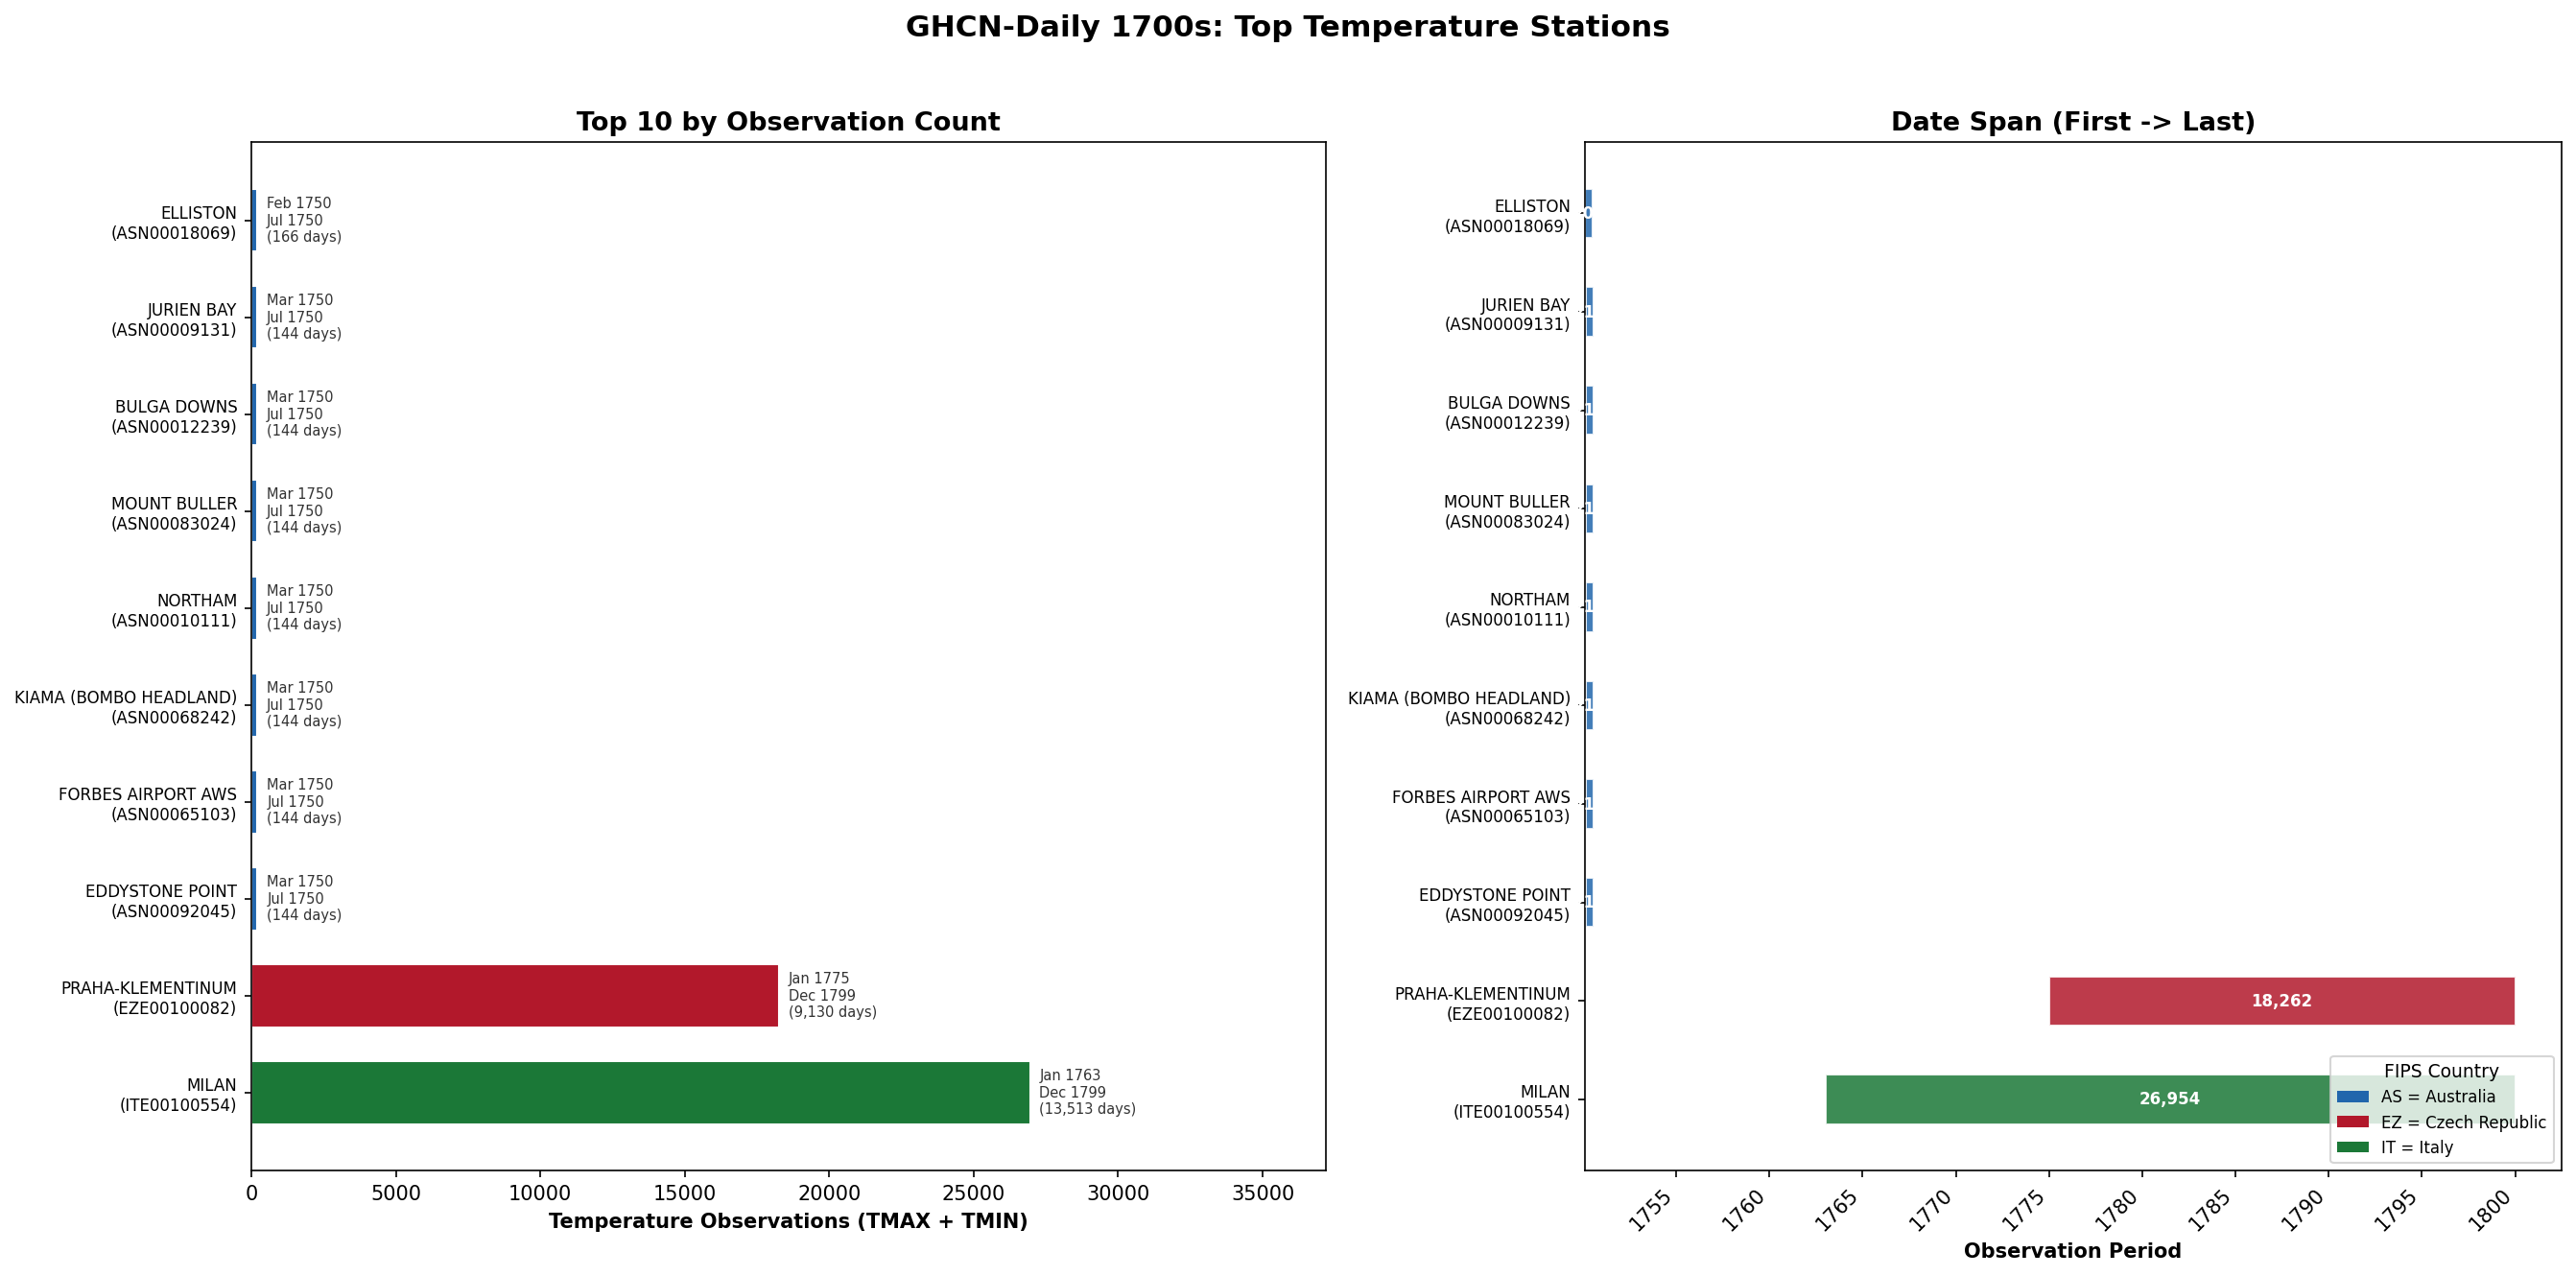

## The top 10 — and the 125× gap

**Ranking by temperature observation count (TMAX + TMIN):**

| # | Station | Name | Country | Obs | First | Last | Span |
|---|---|---|---|---:|---|---|---:|
| 1 | ITE00100554 | **Milan (Brera Observatory)** | Italy | **26,954** | 1763-01-01 | 1799-12-31 | 13,514 days |
| 2 | EZE00100082 | **Praha-Klementinum** | Czech Rep. | **18,262** | 1775-01-01 | 1799-12-31 | 9,131 days |
| 3 | ASN00065103 | Forbes Airport AWS | Australia | 216 | 1750-03-01 | 1750-07-23 | 144 days |
| 4 | ASN00092045 | Eddystone Point | Australia | 216 | 1750-03-01 | 1750-07-23 | 144 days |
| 5 | ASN00068242 | Kiama (Bombo Headland) | Australia | 215 | 1750-03-01 | 1750-07-23 | 144 days |
| 6 | ASN00010111 | Northam | Australia | 213 | 1750-03-01 | 1750-07-23 | 144 days |
| 7 | ASN00012239 | Bulga Downs | Australia | 213 | 1750-03-01 | 1750-07-23 | 144 days |
| 8 | ASN00083024 | Mount Buller | Australia | 213 | 1750-03-01 | 1750-07-23 | 144 days |
| 9 | ASN00009131 | Jurien Bay | Australia | 212 | 1750-03-01 | 1750-07-23 | 144 days |
| 10 | ASN00018069 | Elliston | Australia | 209 | 1750-02-03 | 1750-07-19 | 166 days |

There is a **125× cliff** between rank 2 (18,262 obs) and rank 3 (216 obs). Nothing gradual about it.

## Two genuinely different populations

**The leaders (#1 and #2) are real, long-running European observatories.** Milan's Brera Astronomical Observatory and Prague's Clementinum are both celebrated early-instrumental climate stations — daily max/min temperatures recorded continuously for 37 and 25 years respectively, running right up to 1799-12-31. Milan alone holds nearly **20% of all temperature observations in the entire 1700s partition** (26,954 of 137,616). These two stations account for **33%** of all 18th-century temperature records.

**Ranks #3–#10 are the 1750 Australian anomaly revisited.** All eight are Australian BoM stations with modern names (Forbes Airport AWS, Mount Buller, Eddystone Point) reporting only 144 days of data in 1750 — impossible geography, as established earlier. Their ~215 obs each rank high only because *every other station in the genuine 1763–1799 network reports far less*; the real European tail beyond Milan and Prague is extremely sparse.

## Are the leaders a small cluster or a spread-out network?

**Neither — they're just two isolated points, ~650 km apart.** The genuine long-record temperature network of the 1700s is effectively **two European observatories** : one in Milan, one in Prague. This is not a cluster in any meaningful sense, and it's certainly not a "spread-out network." It's two of the most famous historical meteorological stations in Europe, both run by astronomical observatories that happened to maintain disciplined daily thermometer readings while the rest of the continent's network was still decades away from forming.

**Bottom line:** if you want continuous daily temperature series from the late 1700s, this partition gives you Milan (from 1763) and Prague (from 1775) — and essentially nothing else of comparable depth. Everything else is either the mislabeled 1750 Australian batch or fragmentary short runs.

In [7]:
%%ask
Which stations have the longest temperature records in this dataset?
List the top ten stations by number of daily maximum or minimum
temperature observations, with each station's first and last
observation date. Comment on whether the leaders look like a small
cluster of long-running European stations or a more spread-out
network.